# The Golden Ratio as a Compositional Principle in Book Cover Design. A Comparison with the Rule of Thirds

Project Type: Technical Report

Author: Plami_Georgieva 

Student number: 300245637

Date: March 2026

Table of Contents:
1. Introduction and Problem Statement
   
2. Mathematical Background

   
    2.1. Golden Ratio

   
    2.2. The Fibonacci Matrix

   
    2.3. Linear Transformation of the Golden Ratio in 2D

   
    2.4. The Rule of Thirds

   
4. Comparison of the two compositional principles

   
5. Implementation in book covers: Layoutps and side-by-side Composition Comparison

   
6. Experiments: Simulated Book Cover Layouts

   
7. Analysis and Conclusions


1. Introduction and Problem Statement

The readers always first see the book covers than the pages of the books. So, the book covers are extremely important because they are the first point of contact between a reader and a work. A viewer decides whether a book is worth picking up by the cover. The most important is not the color or the typography but the composition of the elements all together, the spatial arrangement
of visual elements  - the composition. Two compositional elements dominate in the graphic design: 
-The Golden Ratio
-The Rule of Thirds
My project asks the question: How can the Golden Ratio be applied as a compositional grid for book cover design and how does it compare mathematically to the Rule of Thirds?

Problem Statement: Given that most standard book covers fall within a rectangular canvas with an universal proportion as follow width:height ~ 2:3 or roughly 6 x 9 inches I want to:
-define a precise mathematical construction of the Golden Ratio grid and the Rule of Thirds;
-implement both grids in Python;
-compare how each principle guides element placement

Scope: 
-I assume that I work with 2D rectangular canvases

-All visual elements are respresented as rectangles, angles or points for mathematical trackability

-I use coordinate system and grid transformations

2. Mathematical Background
The Golden Ratio comes from Euclid's ancient problem: cut a line so the whole is to the large part as the large part is to the small part. That proportion forces the equation







2.1 The Golden ratio $\varphi$

The Golden Ration is defined as follows : Take a line segment of length a + b and cut it at a point so that:



$$
\frac{a+b}{a} = \frac{a}{b} = \varphi
$$

if b = 1 and a = $\varphi$

$$
\frac{\varphi+1}{\varphi} = \varphi
$$

we solve this and we get 
$$
\varphi + 1 = \varphi^2
$$


$$
\varphi^2 - \varphi - 1 = 0
$$

If we apply the quadratic formula with a = 1, b = -1, c = -1, then we have two solutions

 $$
 \varphi = \frac{-(-1) \pm \sqrt{(-1)^2 - 4(1)(-1)}}{2(1)} = \frac{1 \pm \sqrt{5}}{2}
 $$


In [15]:
import sympy as sp

phi = (1 + sp.sqrt(5)) / 2
phi

import sympy as sp

x = sp.symbols('x')
solutions = sp.solve(x**2 - x - 1, x)
solutions

[1/2 - sqrt(5)/2, 1/2 + sqrt(5)/2]

So, the two solutions are as follows




$$
\varphi = \frac{1+\sqrt{5}}{2}
$$

In [10]:
import sympy as sp

phi = (1 + sp.sqrt(5)) / 2

print("Exact value:")
sp.pprint(phi)

print("\nNumerical value:")
print(sp.N(phi, 12))

Exact value:
1   √5
─ + ──
2   2 

Numerical value:
1.61803398875


In [ ]:
The positive root of 1.61803398875 is the Golden Ratio

$$
\varphi = \frac{1-\sqrt{5}}{2}
$$

In [17]:
import sympy as sp

phi = (1 - sp.sqrt(5)) / 2

print("Exact value:")
sp.pprint(phi)

print("\nNumerical value:")
print(sp.N(phi, 12))

Exact value:
1   √5
─ - ──
2   2 

Numerical value:
-0.618033988750


In [ ]:
2.2 The Fibonacci Matrix
The Golden Ration has a special matrix associated with it called the Fibonacci Matrix

In [22]:
import sympy as sp

A = sp.Matrix([[1,1],
               [1,0]])


$$
A=\begin{pmatrix}
1 & 1 \\
1 & 0
\end{pmatrix}
$$

Its eigenvalues are exactly $\varphi$ and $\psi$

$$
\det(A-\lambda I)=0
\;\Rightarrow\;
(1-\lambda)(0-\lambda)-1=0
\;\Rightarrow\;
\lambda^2-\lambda-1=0
$$

$$
\lambda_1=\varphi=\frac{1+\sqrt{5}}{2},
\\qquad
\lambda_2=\psi=\frac{1-\sqrt{5}{2}
$$

This is the same equation that defines $\varphi$

$$
\lambda_1 = \varphi = \frac{1+\sqrt{5}}{2}, \qquad
\lambda_2 = \psi = \frac{1-\sqrt{5}}{2}
$$

In [ ]:
The eigenvectors are:


$$
v_1 =
\begin{pmatrix}
\varphi \\
1
\end{pmatrix},
\qquad
v_2 =
\begin{pmatrix}
\psi \\
1
\end{pmatrix}
$$

2.3 Linear Transformation of the Golden Ratio 


If I want to stretch the golden ratio in such a way that $\varphi$ to be far from 1, I will explicit it in mathematical equation as follows:


Since 
$$
\varphi - 1 = \frac{1}{\varphi},
$$

we can stretch its ''excess over 1" as

$$
r = 1 + s(\varphi - 1)
$$

This keeps $r = 1$ fixed and stretches the distance from $1$

"s" is the stretch factor and if $s=1$ then we have no change

if $s > 1$ then ratio moves farther from 1 and the equation is

$$
r = 1 + s(\varphi - 1)
$$

if $0 < s < 1$ then ratio moves closer to $1$

Example

If $s = 2$:

$$
r = 1 + 2(\varphi - 1)
$$

Since

$$
\varphi - 1 \approx 0.618
$$

then

$$
r \approx 1 + 2(0.618) = 2.236
$$

for 2D stretching of Golden Ratio along coordinate axes, I will use a diagonal matrix:

$$
A =
\begin{pmatrix}
s_x & 0 \\
0 & s_y
\end{pmatrix}
$$

$$
\det(T)=s_x s_y
$$




where
$s_x$ = stretch factor in the $x$-direction;
$s_y$ = stretch factor in the $y$-direction

If we have a transformation by rotation but not a shrinking then the determinant is equal to 1 and the new size is equal to the old one. In other words the we have a preservance of shape/ratio

Visualization of golden ration with Python and then stretchinh far away from 1

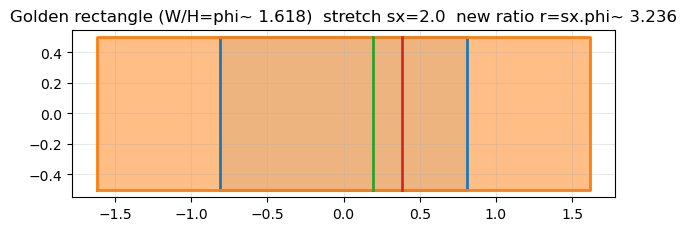

In [46]:
import numpy as np
import matplotlib.pyplot as plt


PHI = (1 + np.sqrt(5)) / 2

def golden_rectangle_corners(cx=0.0, cy=0.0):
    # width = PHI, height = 1

    w, h = PHI/2, 0.5
    return np.array([
    [cx - w, cy - h], # bottom-left
    [cx + w, cy - h], # bottom-right
    [cx + w, cy + h], # top-right
    [cx - w, cy + h], # top-left
    ])

def apply_transformation(corners, A) :
        return corners @ A.T

def draw_quad(ax, pts, alpha=0.25, lw=2):
            closed = np.vstack([pts, pts[0]])
            ax.fill(pts[:,0], pts[:,1], alpha=alpha)
            ax.plot(closed[:,0], closed[:,1], linewidth=lw)

sx=2.0
A = np.array([[sx, 0.0],
              [0.0, 1.0]])
orig = golden_rectangle_corners()
stretched = apply_transformation(orig, A)

new_ratio = sx * PHI

fig, ax = plt.subplots(figsize=(7, 4))
draw_quad(ax, orig, alpha=0.15, lw=2)        # original
draw_quad(ax, stretched, alpha=0.50, lw=2)   # stretched

# original rectangle bounds
xL, xR = orig[:,0].min(), orig[:,0].max()
yB, yT = orig[:,1].min(), orig[:,1].max()

# golden cut position: 1 unit from the left edge (since width = PHI)
x_g = xL + 1.0
ax.plot([x_g, x_g], [yB, yT], linewidth=2) # line inside original

# stretched rectangle bounds
xL2, xR2 = stretched[:,0].min(), stretched[:,0].max()
yB2, yT2 = stretched[:,1].min(), stretched[:,1].max()

# after horizontal stretch by sx, the "1 unit" becomes six units
x_g2 = xL2 + sx*1.0
ax.plot([x_g2, x_g2], [yB2, yT2], linewidth=2) # line inside the stretched

ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Golden rectangle (W/H=phi~{PHI: .3f})  stretch sx={sx}  new ratio r=sx.phi~{new_ratio: .3f}")
ax.grid(True, alpha=0.3)
plt.show()
    

2.3 The Rule of Thirds

The **Rule of Thirds** is another compositional principle where an image is divided into three equal parts horizontally and vertically like divide the frame into a $3 \times 3$ grid by two equally spaced horizontal lines and two equally spaced vertical lines. The four **intersection points** (called *power points* or *crash points*) are considered strong focal positions.

The dividing lines are placed at:

$$x = \frac{W}{3}, \quad x = \frac{2W}{3}, \qquad y = \frac{H}{3}, \quad y = \frac{2H}{3}$$

where $W$ and $H$ are the canvas width and height.

The rule of thirds is a **uniform rational approximation** to the golden ratio division: the nearest power point in the rule of thirds sits at $1/3 \approx 0.333$ or $2/3 \approx 0.667$ of the canvas dimension, while the golden ratio division places a point at:

$$\frac{1}{\varphi} = \frac{1}{1.618} \approx 0.618$$

and its complement at $1 - 0.618 = 0.382$.

The mathematical "distance" between the two systems:

$$\Delta = \frac{1}{\varphi} - \frac{2}{3} = 0.618 - 0.667 \approx -0.049$$

This roughly 5% difference will manifest visibly in the grid comparisons below.

3. Comparison of the two compositional principles

  
| Property | Golden Ratio (φ) | Rule of Thirds |
|---|---|---|
| Division ratio | 0.382 : 0.618 (irrational) | 0.333 : 0.667 (rational) |
| Number of power points | 4 (from 2 lines × 2 lines) | 4 |
| Mathematical origin | Quadratic equation / infinite continued fractions | Simple fraction $1/3$ |
| Self-similarity | Yes (nested Golden Rectangles) | No |
| Spiral connection | Yes (Golden / logarithmic spiral) | No |
| Ease of use | Requires measurement or tools | Easy to estimate by eye |
| Used in | Classical art, architecture, typography, nature | Photography, digital design, filmmaking |

The Golden Ratio system offers richer mathematical structure but requires more deliberate application. The Rule of Thirds is a practical approximation that is easier to apply intuitively. 

In [ ]:
4. Implementation of the two principles in book covers: Layouts

    4.1. Generating a Golden Rectangle Grid

### 4.3 Generating the Golden Ratio Grid on a Book Cover

A **Golden Ratio grid** is constructed by subdividing the canvas width $W$ and height $H$ at the golden ratio divison points:

- **Vertical guide lines** at $x = W / \varphi$ and $x = W \cdot (1 - 1/\varphi)$
- **Horizontal guide lines** at $y = H / \varphi$ and $y = H \cdot (1 - 1/\varphi)$

Note that $W/\varphi = W \cdot (\varphi - 1) = W \cdot 0.382$, placing the first line at 38.2% of the width.

    

In [54]:
import math 
# Image / cover dimensions
COVER_W = 600
COVER_H = 900

PHI = (1 +  math.sqrt(5)) / 2
PHI_INV = 1 / PHI


def golden_grid_lines(width: float, height: float) -> dict:
    """
    Compute Golden Ratio guide lines for a canvas of given width and height.

    Returns a dict with:
        'vertical'   : list of x positions
        'horizontal' : list of y positions
        'power_points': list of (x, y) intersection coordinates
    """
    # Primary division: width × (1/φ) ≈ 0.618 × width
    # Secondary (complement): width × (1 - 1/φ) ≈ 0.382 × width
    vlines = sorted([width * PHI_INV, width * (1 - PHI_INV)])
    hlines = sorted([height * PHI_INV, height * (1 - PHI_INV)])

    power_pts = [(x, y) for x in vlines for y in hlines]

    return {'vertical': vlines, 'horizontal': hlines, 'power_points': power_pts}


def thirds_grid_lines(width: float, height: float) -> dict:
    """Compute Rule-of-Thirds guide lines."""
    vlines = [width / 3, 2 * width / 3]
    hlines = [height / 3, 2 * height / 3]
    power_pts = [(x, y) for x in vlines for y in hlines]
    return {'vertical': vlines, 'horizontal': hlines, 'power_points': power_pts}


# ── Numerical report ─────────────────────────────────────────────────────────
golden = golden_grid_lines(COVER_W, COVER_H)
thirds = thirds_grid_lines(COVER_W, COVER_H)

print("=== GOLDEN RATIO GRID ===")
print(f"  Vertical lines (x):   {[f'{v:.4f}' for v in golden['vertical']]}")
print(f"  Horizontal lines (y): {[f'{v:.4f}' for v in golden['horizontal']]}")
print(f"  Power points (x,y):   {[(f'{x:.4f}', f'{y:.4f}') for x,y in golden['power_points']]}")

print("\n=== RULE OF THIRDS GRID ===")
print(f"  Vertical lines (x):   {[f'{v:.4f}' for v in thirds['vertical']]}")
print(f"  Horizontal lines (y): {[f'{v:.4f}' for v in thirds['horizontal']]}")
print(f"  Power points (x,y):   {[(f'{x:.4f}', f'{y:.4f}') for x,y in thirds['power_points']]}")

print(f"\nDifference in first vertical guide: {abs(golden['vertical'][0] - thirds['vertical'][0]):.4f}")

=== GOLDEN RATIO GRID ===
  Vertical lines (x):   ['229.1796', '370.8204']
  Horizontal lines (y): ['343.7694', '556.2306']
  Power points (x,y):   [('229.1796', '343.7694'), ('229.1796', '556.2306'), ('370.8204', '343.7694'), ('370.8204', '556.2306')]

=== RULE OF THIRDS GRID ===
  Vertical lines (x):   ['200.0000', '400.0000']
  Horizontal lines (y): ['300.0000', '600.0000']
  Power points (x,y):   [('200.0000', '300.0000'), ('200.0000', '600.0000'), ('400.0000', '300.0000'), ('400.0000', '600.0000')]

Difference in first vertical guide: 29.1796


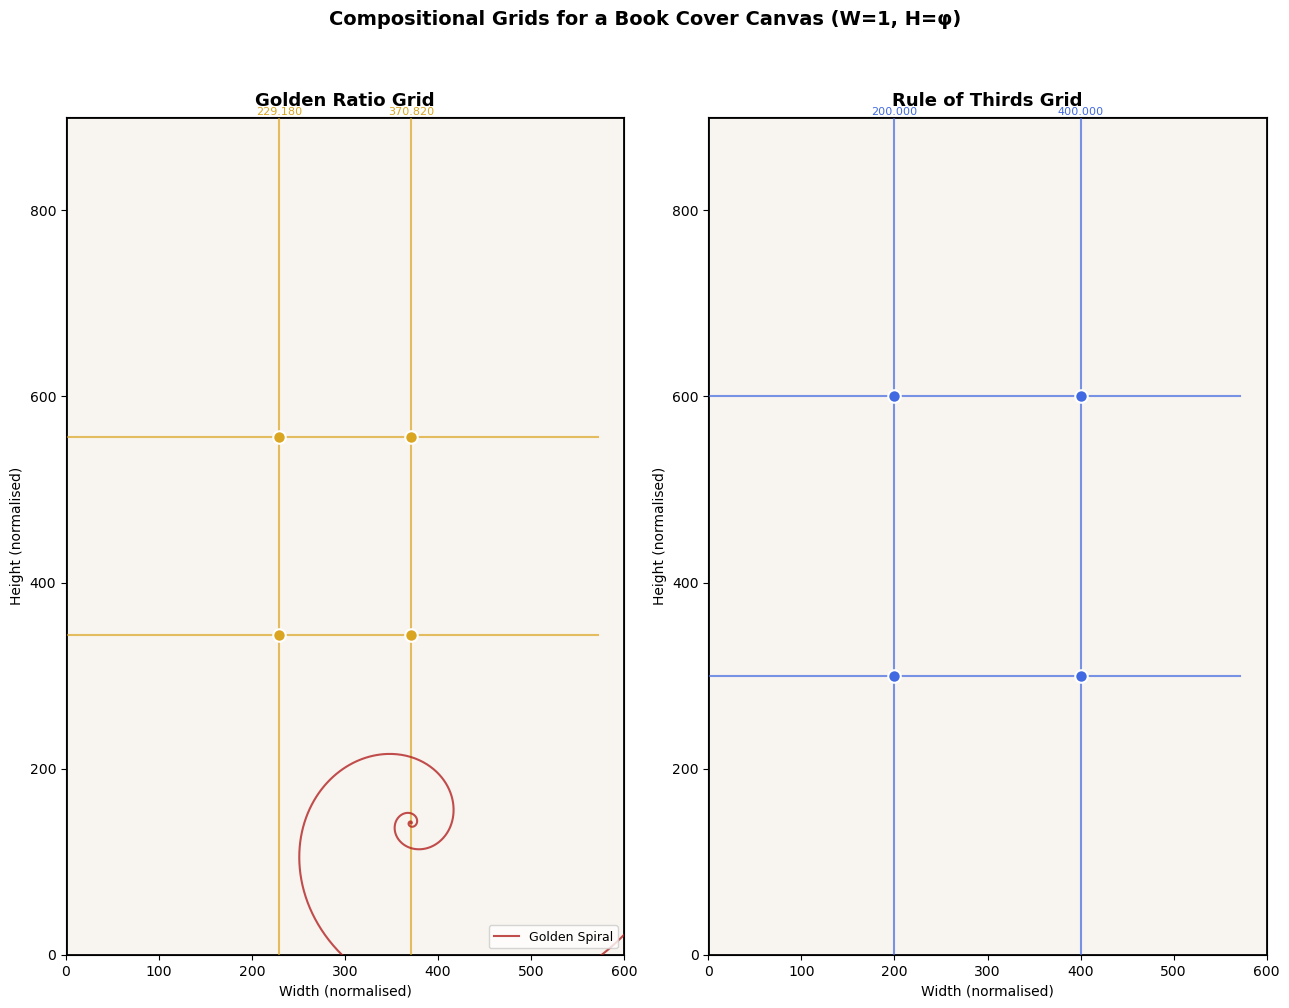

Figure 2 saved.


In [56]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as patches

def golden_spiral_points(x0: float, y0: float, width: float, n_turns: float = 3.5,
                          n_points: int = 1000) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute (x, y) points of a Golden Spiral placed in the top-right of a rectangle.

    The spiral is defined by the polar equation r(θ) = a · exp(b · θ)
    where b = 2·ln(φ)/π so that the radius multiplies by φ per quarter turn.

    Parameters
    ----------
    x0, y0  : bottom-left corner of the bounding rectangle
    width   : width of the bounding rectangle
    n_turns : number of full turns to draw
    n_points: number of sample points
    """
    b = 2 * math.log(PHI) / math.pi   # growth rate
    a = width / (2 * math.exp(b * 2 * math.pi * n_turns))  # scale to fit

    theta = np.linspace(0, 2 * math.pi * n_turns, n_points)
    r = a * np.exp(b * theta)

    # Centre the spiral at the top-right power point
    cx = x0 + width * PHI_INV          # ≈ 0.618 × W from left
    cy = y0 + width / PHI * (1 - PHI_INV)  # approximate centring

    xs = cx + r * np.cos(theta - math.pi)
    ys = cy + r * np.sin(theta - math.pi)
    return xs, ys


def draw_grid(ax, grid: dict, color: str, label: str,
              width: float, height: float):
    """Draw grid lines and power points onto a Matplotlib axes."""
    # Boundary rectangle
    rect = patches.Rectangle((0, 0), width, height,
                               linewidth=2, edgecolor='black', facecolor='#f8f4ef')
    ax.add_patch(rect)

    for x in grid['vertical']:
        ax.axvline(x, ymin=0, ymax=height / ax.get_ylim()[1],
                   color=color, linewidth=1.5, alpha=0.7)
    for y in grid['horizontal']:
        ax.axhline(y, xmin=0, xmax=width / ax.get_xlim()[1],
                   color=color, linewidth=1.5, alpha=0.7)

    for (px, py) in grid['power_points']:
        ax.plot(px, py, 'o', color=color, markersize=9, zorder=5,
                markeredgecolor='white', markeredgewidth=1.5)

    ax.set_xlim(0, width + 0.05)
    ax.set_ylim(0, height + 0.05)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel("Width (normalised)", fontsize=10)
    ax.set_ylabel("Height (normalised)", fontsize=10)


# ── Figure 2: Golden Grid vs Rule of Thirds ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 10))

draw_grid(axes[0], golden, color='goldenrod',
          label='Golden Ratio Grid', width=COVER_W, height=COVER_H)

# Add Golden Spiral
sx, sy = golden_spiral_points(0, 0, COVER_W, n_turns=3.5)
axes[0].plot(sx, sy, color='firebrick', linewidth=1.5, alpha=0.8, label='Golden Spiral')
axes[0].legend(loc='lower right', fontsize=9)

# Annotate division ratios
for x in golden['vertical']:
    axes[0].annotate(f'{x:.3f}', xy=(x, COVER_H + 0.02),
                     ha='center', va='bottom', fontsize=8, color='goldenrod')

draw_grid(axes[1], thirds, color='royalblue',
          label='Rule of Thirds Grid', width=COVER_W, height=COVER_H)

for x in thirds['vertical']:
    axes[1].annotate(f'{x:.3f}', xy=(x, COVER_H + 0.02),
                     ha='center', va='bottom', fontsize=8, color='royalblue')

plt.suptitle('Compositional Grids for a Book Cover Canvas (W=1, H=φ)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig02_grid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

5. Experiments: Simulated Book Cover Layouts
   
We now simulate three archetypal book-cover layout types 

### Layout Types

| Layout | Description |
|--------|-------------|
| **L1 – Classic fiction** | Large top title, central image, bottom author name |
| **L2 – Grid-aligned (Golden)** | All elements deliberately placed on golden power points |
| **L3 – Grid-aligned (Thirds)** | All elements deliberately placed on thirds power points |

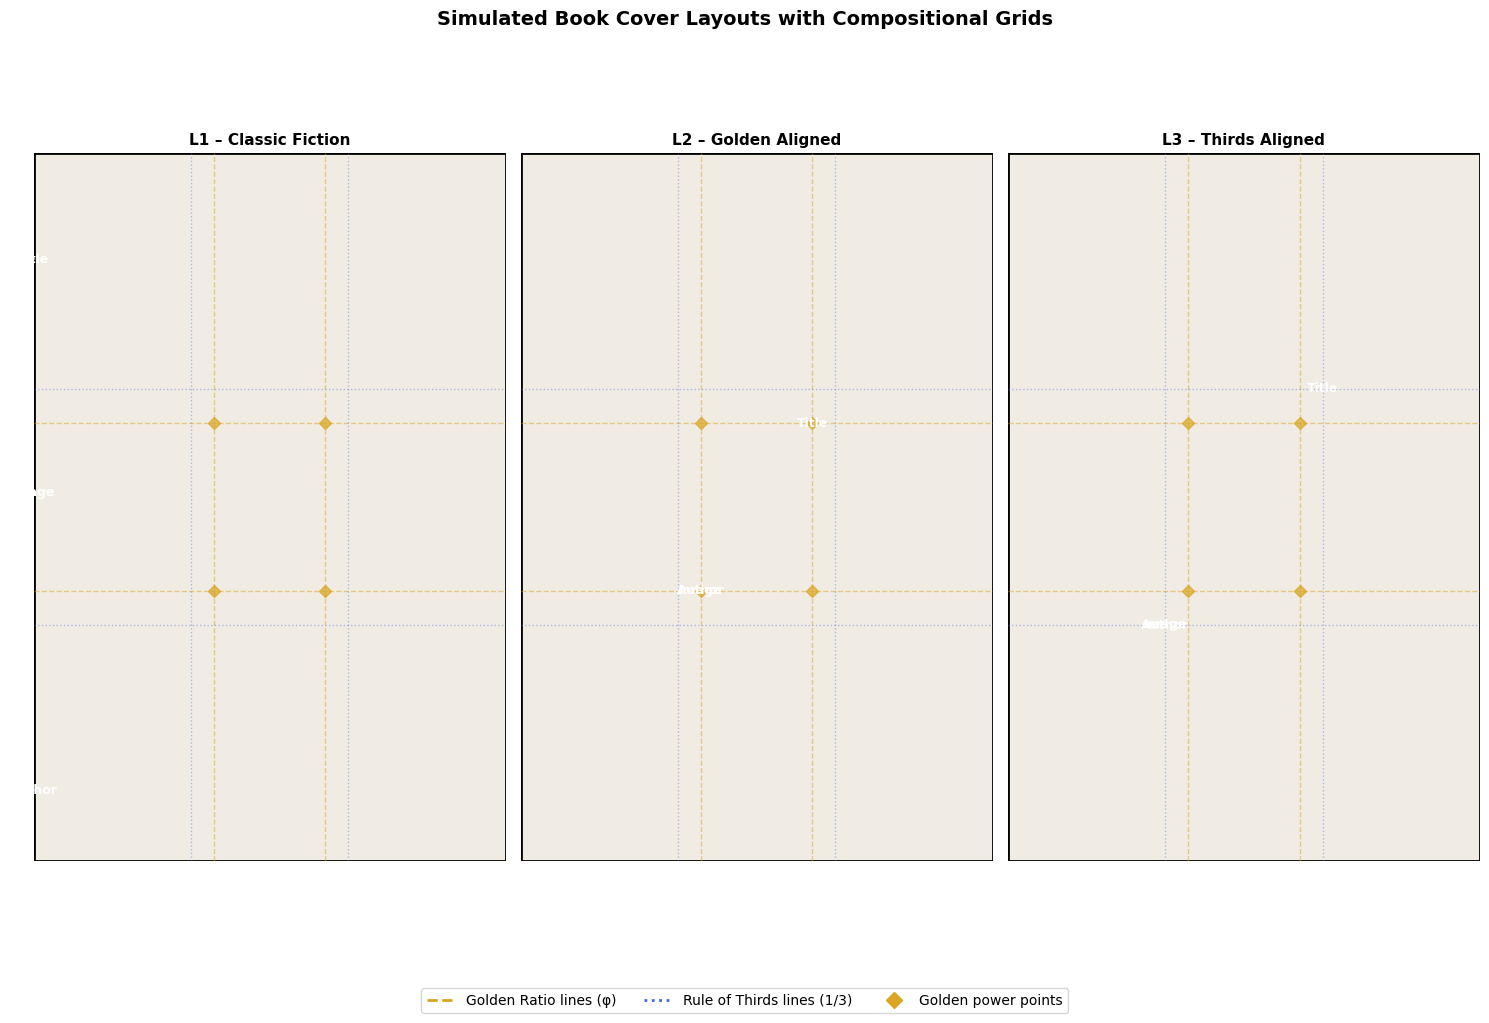

Figure 4 saved.


In [57]:
# ── Layout definitions ─────────────────────────────────────────────────────
# Each layout is a list of dicts:
#   name  : element name
#   cx, cy: centre of element (normalised coords, y=0 at bottom)
#   w, h  : width and height of element
#   color : display colour

def make_rect(cx, cy, w, h):
    """Return (x0, y0, w, h) from centre and dimensions."""
    return cx - w / 2, cy - h / 2, w, h


gv = golden['vertical']    # [0.382, 0.618]
gh = golden['horizontal']  # [0.618·H,  0.382·H]
tv = thirds['vertical']    # [1/3,  2/3]
th = thirds['horizontal']  # [H/3,  2H/3]

layouts = {
    'L1 – Classic Fiction': [
        {'name': 'Title',    'cx': 0.50, 'cy': COVER_H * 0.85, 'w': 0.80, 'h': 0.20, 'color': '#3a3a8c'},
        {'name': 'Image',    'cx': 0.50, 'cy': COVER_H * 0.52, 'w': 0.70, 'h': 0.60, 'color': '#7cb87c'},
        {'name': 'Author',   'cx': 0.50, 'cy': COVER_H * 0.10, 'w': 0.60, 'h': 0.12, 'color': '#b87c7c'},
    ],
    'L2 – Golden Aligned': [
        {'name': 'Title',    'cx': gv[1], 'cy': gh[1], 'w': 0.70, 'h': 0.18, 'color': '#3a3a8c'},
        {'name': 'Image',    'cx': gv[0], 'cy': gh[0] + 0.20, 'w': 0.60, 'h': 0.55, 'color': '#7cb87c'},
        {'name': 'Author',   'cx': gv[0], 'cy': gh[0] - 0.15, 'w': 0.55, 'h': 0.12, 'color': '#b87c7c'},
    ],
    'L3 – Thirds Aligned': [
        {'name': 'Title',    'cx': tv[1], 'cy': th[1], 'w': 0.70, 'h': 0.18, 'color': '#3a3a8c'},
        {'name': 'Image',    'cx': tv[0], 'cy': th[0] + 0.20, 'w': 0.60, 'h': 0.55, 'color': '#7cb87c'},
        {'name': 'Author',   'cx': tv[0], 'cy': th[0] - 0.15, 'w': 0.55, 'h': 0.12, 'color': '#b87c7c'},
    ],
}


def draw_book_cover(ax, elements: list, title: str,
                    golden_grid: dict, thirds_grid: dict,
                    width: float, height: float):
    """Draw a simulated book cover with both compositional grids overlaid."""
    # Background
    bg = patches.Rectangle((0, 0), width, height, facecolor='#f0ece4', edgecolor='black', lw=2)
    ax.add_patch(bg)

    # Golden grid (light)
    for x in golden_grid['vertical']:
        ax.axvline(x, color='goldenrod', lw=1.0, alpha=0.5, linestyle='--')
    for y in golden_grid['horizontal']:
        ax.axhline(y, color='goldenrod', lw=1.0, alpha=0.5, linestyle='--')
    for (px, py) in golden_grid['power_points']:
        ax.plot(px, py, 'D', color='goldenrod', ms=6, zorder=4, alpha=0.7)

    # Thirds grid (light)
    for x in thirds_grid['vertical']:
        ax.axvline(x, color='royalblue', lw=1.0, alpha=0.4, linestyle=':')
    for y in thirds_grid['horizontal']:
        ax.axhline(y, color='royalblue', lw=1.0, alpha=0.4, linestyle=':')

    # Elements
    for elem in elements:
        x0, y0, w, h = make_rect(elem['cx'], elem['cy'], elem['w'], elem['h'])
        r = patches.FancyBboxPatch((x0, y0), w, h,
                                    boxstyle="round,pad=0.01",
                                    facecolor=elem['color'], alpha=0.75,
                                    edgecolor='white', lw=1.5, zorder=3)
        ax.add_patch(r)
        ax.text(elem['cx'], elem['cy'], elem['name'],
                ha='center', va='center', fontsize=9, color='white',
                fontweight='bold', zorder=5)

    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    ax.axis('off')


fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (layout_name, elems) in zip(axes, layouts.items()):
    draw_book_cover(ax, elems, layout_name, golden, thirds, COVER_W, COVER_H)

# Legend
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color='goldenrod', lw=2, linestyle='--', label='Golden Ratio lines (φ)'),
    Line2D([0], [0], color='royalblue', lw=2, linestyle=':', label='Rule of Thirds lines (1/3)'),
    Line2D([0], [0], marker='D', color='goldenrod', lw=0, ms=8, label='Golden power points'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Simulated Book Cover Layouts with Compositional Grids',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig04_layout_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

6. Analysis and Conclusion

   
The key mathematical observation is the difference in *division ratios*:

$$\text{Golden division: } \frac{1}{\varphi} \approx 0.618 \qquad \text{Thirds division: } \frac{2}{3} \approx 0.667$$

The discrepancy of about $0.049$ (5% of the canvas width) is small but visually perceptible, especially in layouts where precision matters.

The Golden Ratio grid has a richer algebraic structure:
- It is self-similar: subdividing the canvas with the golden ratio produces nested golden rectangles.
- It generates a logarithmic spiral, which appears throughout nature (nautilus shells, galaxy arms, hurricane eyes).
- The Fibonacci sequence is a discrete integer approximation to the continuous ratio.

    Practical Design Trade-offs

| Criterion | Golden Ratio | Rule of Thirds |
|---|---|---|
| Mathematical richness | Very high (spiral, self-similarity, irrationality) | Low (simple 1/3 fraction) |
| Precision in application | Requires tools or computation | Can be approximated by eye |
| Historical pedigree | Ancient (Euclid, Vitruvius, Renaissance art) | Modern (19th-century art instruction) |
| Applicable to text typography | Yes (text blocks, margin proportions) | Partially |
| Scientific evidence for superiority | Contested — some studies support, many do not | Contested |
| Best use case | Logo design, classical book typography, fine art | Photography, web design, film composition |

Limitations of this Study

1. Elements are modelled as **points** (centroids), ignoring their spatial extent.
2. No **user perception study** was conducted — we cannot claim that one system looks "better" to human observers.
3. We used a **single canvas aspect ratio** (2:3). Different formats (square, wide-screen) may change the relative performance.
4. The alignment score metric is a **mathematical proxy** — it does not capture concepts like visual balance, contrast, or hierarchy.



In [59]:
# ── Summary statistics table ─────────────────────────────────────────────────
print("=" * 60)
print("SUMMARY: Key Mathematical Values")
print("=" * 60)
print(f"  φ = (1 + √5) / 2        = {PHI:.10f}")
print(f"  1/φ = φ − 1             = {PHI_INV:.10f}")
print(f"  1 − 1/φ                 = {1 - PHI_INV:.10f}")
print(f"  Fibonacci convergence F(15)/F(14) = {fibonacci(16)[-1] / fibonacci(16)[-2]:.10f}")
print()
print("=" * 60)
print("SUMMARY: Grid Comparison")
print("=" * 60)
print(f"  Golden vertical guide at  x = {golden['vertical'][0]:.4f} and {golden['vertical'][1]:.4f}")
print(f"  Thirds vertical guide at  x = {thirds['vertical'][0]:.4f} and {thirds['vertical'][1]:.4f}")
print(f"  Difference in first guide:  Δ = {abs(golden['vertical'][0] - thirds['vertical'][0]):.4f}")
print()
print("=" * 60)


SUMMARY: Key Mathematical Values
  φ = (1 + √5) / 2        = 1.6180339887
  1/φ = φ − 1             = 0.6180339887
  1 − 1/φ                 = 0.3819660113


NameError: name 'fibonacci' is not defined